CIFAR-10: image classification of real-world images (airplane, car, bird, cat, ...) using a CNN.

the class mapping is:

0 → airplane
1 → automobile
2 → bird
3 → cat
4 → deer
5 → dog
6 → frog
7 → horse
8 → ship
9 → truck

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.cifar10.load_data()

In [3]:
print("Training images:",X_train.shape)
print("Training labels:",y_train.shape)

print("Test images:",X_test.shape)
print("Test labels:",y_test.shape)

Training images: (50000, 32, 32, 3)
Training labels: (50000, 1)
Test images: (10000, 32, 32, 3)
Test labels: (10000, 1)


In [4]:
X_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

(50000, 1) means the data is arranged as a 2-dimensional array:

50000 rows × 1 column

So it looks conceptually like:

[ [6],
  [2],
  [9],
  [4],
  ... ]

Each row contains one value, so each label is wrapped inside a one-element array.
That's why:

y_train[0]      → [6]
y_train[0][0]   → 6



Whereas (50000,) means a 1-dimensional array:
[6, 2, 9, 4, ...]
so:
y_train[0] → 6


X_train → (60000, 28, 28) 
60000 images
   ↓
each image = 28 × 28

X_train[0]
means first image. One [0] is enough because you're selecting one item from the 60,000 images.



In CIFAR-10:
X_train → (50000, 32, 32, 3)
y_train → (50000, 1)

So:

X_train[0]      # first image
y_train[0]      # [6]
y_train[0][0]   # 6

CIFAR-10 images are RGB/color images, not grayscale.

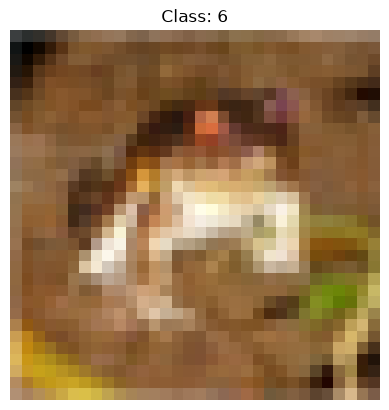

In [5]:
#look at one image:
plt.imshow(X_train[0])
plt.title(f"Class: {y_train[0][0]}")
plt.axis("off")
plt.show()

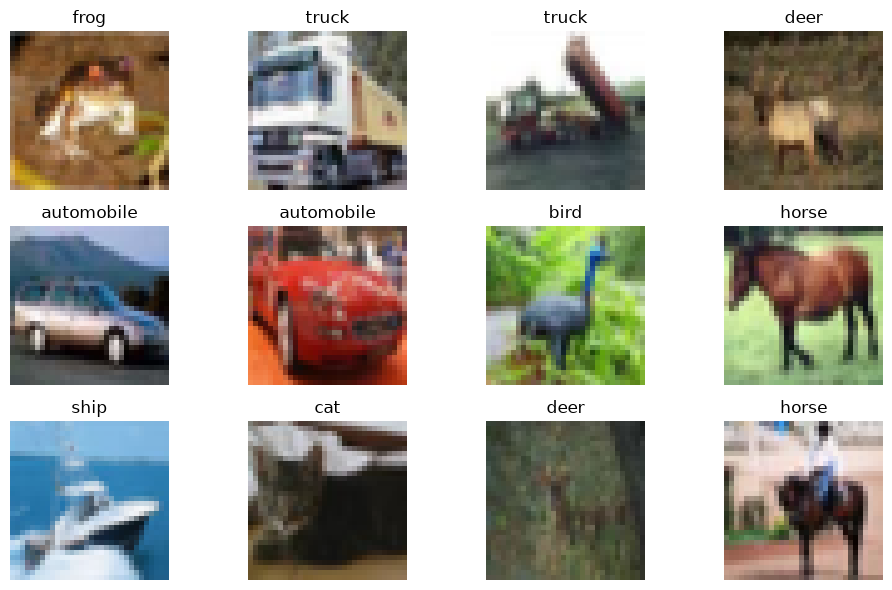

In [6]:
#This will show 12 images along with their actual class names instead of just numbers like 6.
#y_train[i] is still an array containing one value.

#class_names[6]
# "frog"
#So the flow is:

#y_train[i]       → [6]
#y_train[i][0]    → 6
#class_names[6]   → "frog"
#The 0 does not mean class zero. It means “take the first (and only) element of this array.”


class_names=["airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

plt.figure(figsize=(10,6))

for i in range(12):
    plt.subplot(3,4,i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.show()





The titles are the actual CIFAR-10 class labels converted from numbers into names.

In [7]:
#normalize the images
#float32 is a good explicit practice, not a CNN requirement.It is a good consistent practice, even though it isn't strictly required if the data is already floating-point.


X_train = X_train.astype("float32") /255.0
X_test=X_test.astype('float32')/255.0

#We normalized the pixel values of every image in both X_train and X_test.

In [8]:
print(X_train.min())
print(X_train.max())

0.0
1.0


After normalization:
0.0 to 1.0
So every pixel in every CIFAR-10 image is now scaled to the 0–1 range.

In [9]:
from tensorflow.keras import layers,models
model=models.Sequential([
    layers.Conv2D(32,(3,3),
                  activation='relu',
                  input_shape=(32,32,3),
                  ), 
                  layers.MaxPooling2D((2,2)),
                  layers.Conv2D(
                      64,
                      (3,3),
                      activation='relu'

                  ),
                  layers.MaxPooling2D((2,2)),
                  layers.Flatten(),
                  layers.Dense(64,activation='relu'),
                  layers.Dense(10,activation='softmax')
])


r:\C\PYTHON PROGRAMS\Deep Learning Proj 2 (CNN proj 1)\.venv-1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


layers.Conv2D(32, (3,3), ...)
means:
32 → 32 filters
(3,3) → each filter has a 3×3 spatial size

Then:
layers.MaxPooling2D((2,2))
means the pooling window is 2×2.

MaxPooling2D((2,2)) means:
Take every 2×2 region of the feature map and replace it with one maximum value

It does not mean the final feature map becomes 2×2. Rather, every 2×2 region of the feature map is reduced to one maximum value, making the overall feature map smaller.(2,2) only tells us the pooling window size, not the final output size.

Then:
layers.Conv2D(64, (3,3), ...)

means the second convolutional layer learns 64 filters, each with a 3×3 spatial size.

Then we again apply:

layers.MaxPooling2D((2,2))

to reduce the spatial dimensions further.



We don't always write:

input_shape=(32,32,3)

That's specific to this CIFAR-10 dataset.

For example:

CIFAR-10 → (32,32,3)
MNIST     → (28,28,1)  if using CNN

The input shape must match the dataset's image shape.

Why Flatten()?

After the convolution and pooling layers, we have something like:

Feature maps
      ↓
3D structure
(height × width × channels)

For example, conceptually:

6 × 6 × 64

The Dense layer expects a 1D vector, not a 3D feature-map structure.

So:

layers.Flatten()

converts:

6 × 6 × 64

into:

2304 values

Then we can do:

Flatten
   ↓
Dense(64)
   ↓
Dense(10)

So the overall logic is:

Image
 ↓
Conv2D → extract features
 ↓
MaxPooling → reduce spatial size
 ↓
Conv2D → learn more complex features
 ↓
MaxPooling → reduce again
 ↓
Flatten → convert 3D feature representation into 1D
 ↓
Dense → classify

And that is why Flatten comes after the convolution/pooling part: we first want CNNs to extract spatial features, and only then hand those extracted features to the fully connected classifier.

PART 1: Feature extraction
Image
 ↓
Conv2D
 ↓
MaxPooling
 ↓
Conv2D
 ↓
MaxPooling

These layers extract visual features.

Then:

PART 2: Classification
 ↓
Flatten
 ↓
Dense(64)
 ↓
Dense(10)
Why Dense(64)?

After Flatten, we have a long vector of extracted features.

Dense(64) is a fully connected layer with 64 neurons. It takes those extracted features and learns combinations of them that are useful for deciding the class.

So:

CNN layers → "What features are present?"
Dense layers → "Based on these features, what class is this?"

Dense(10, activation="softmax")
because CIFAR-10 has 10 classes, so it produces 10 output probabilities.

Convolution + Pooling
        ↓
     Flatten
        ↓
   1D feature vector
        ↓
   Dense(64)
        ↓
   Dense(10)
        ↓
   10 probabilities

   The Dense(64) acts as a classifier layer that combines the extracted features before the final 10-class prediction.

   you will usually put a Dense layer after Flatten, but it does not have to be exactly Dense(64). The number of neurons is a design choice.

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Each CIFAR-10 image is:
32 × 32 pixels
And because it is an RGB color image:
32 × 32 × 3

So 32 × 32 is the spatial dimension, and 3 represents the RGB channels.

and by default Keras uses padding="valid" and stride=1.

30 × 30 is the size of each feature map after the first convolution.

Your original image is:
32 × 32 × 3

You use a 3×3 filter, stride 1, and no padding:
(32 - 3) / 1 + 1 = 30

You defined 32 filters, each with a 3×3 spatial size. The output:

(30, 30, 32)

does not mean your filters became 30×30.

It means:

30 × 30 → size of EACH feature map
32     → number of feature maps

Why 30×30?

Your input image is:

32 × 32 × 3

A 3×3 filter moves across the image with stride 1 and no padding.

Horizontally, it can start at:

column 1
column 2
...
column 30

So there are 30 positions horizontally.

The same happens vertically → 30 positions vertically.

Therefore one 3×3 filter produces one 30×30 feature map.

Since you have 32 filters:

1 filter  → 30 × 30 feature map
32 filters → 30 × 30 × 32

Original image:
32 × 32 × 3

After applying a 3×3 filter with stride 1 and no padding, the filter can be placed only at 30 positions horizontally:

32 - 3 + 1 = 30

So the image still has 32 columns; the output feature map has 30 columns.

Think:

32 columns in input
↓
3 columns are occupied by filter
↓
30 possible starting positions

That's why the output is:

30 × 30 × 32

not because the original image had 30 columns.



one image gets all 32 filters.

Think of it like this:

One image
   ↓
Filter 1 → Feature map 1
Filter 2 → Feature map 2
Filter 3 → Feature map 3
...
Filter 32 → Feature map 32

So one image → 32 filters → 32 feature maps.

Then the same 32 filters are reused for image 2, image 3, ... all 50,000 images.

So 32 means 32 different pattern detectors, not 32 images.

The 896 parameters belong to the Conv2D layer, not to one image.

For one image:

32 filters
↓
each filter has 27 weights + 1 bias
↓
32 × 28 = 896 learnable parameters

But those same 896 parameters are reused for every image:

Image 1  → uses the same 896 parameters
Image 2  → uses the same 896 parameters
Image 3  → uses the same 896 parameters
...
Image 50,000 → uses the same 896 parameters

So don't think:

1 image = 896 parameters.

Think:

1 Conv2D layer = 896 learnable parameters, and those parameters are shared across all images.

That's called weight sharing, and it's a fundamental CNN concept.

The 896 parameters are shared across all images, and different filters (groups of those parameters) learn to detect different patterns, such as:

edges
textures
corners
shapes

So it's more accurate to say each filter learns a different feature, not each individual parameter.

The 32 feature maps remain 32 because pooling does not change the number of feature maps.

For each feature map:

30 × 30
   ↓ MaxPooling(2,2)
15 × 15

because each 2×2 region becomes one maximum value.

So:

30 × 30 × 32
        ↓
15 × 15 × 32

And parameters = 0 because MaxPooling has no learnable weights or biases. It simply selects the maximum value from each 2×2 region.

Now the second convolution + second pooling:
Second Conv2D

Input to 2nd Conv2D: 15 × 15 × 32
              ↓
64 filters
              ↓
Each filter → 13 × 13 feature map
              ↓
64 filters → 64 feature maps
              ↓
Output = 13 × 13 × 64

One image is passed through all 64 filters in that second convolutional layer.
The 18,496 comes from the parameters inside each of the 64 filters:

One filter:
3 × 3 × 32 = 288 weights
+ 1 bias
= 289 parameters

Then there are 64 filters:

289 × 64 = 18,496

So:

18,496 = parameters of the 64 filters together.
So 18,496 is the total learnable parameters of that layer, shared across all images.

You have:
13 × 13 × 64

That means 64 separate feature maps, each of size 13 × 13.

MaxPooling (2,2) is applied to each feature map separately:

13 × 13 → 6 × 6

So after pooling:

13 × 13 × 64
       ↓
6 × 6 × 64

Therefore:
Each of the 64 feature maps becomes 6 × 6. We do NOT end up with only one feature map.

filters are what create the feature maps.

For the second convolution:

64 filters
   ↓
64 feature maps

Then MaxPooling works on those 64 feature maps individually:

64 feature maps, each 13×13
        ↓ MaxPooling(2×2)
64 feature maps, each 6×6

So the 64 stays the same. Only the spatial size changes:

13 × 13 × 64
      ↓
6 × 6 × 64

6 × 6 = spatial dimensions of the feature map
64 = number of feature maps/channels produced by the second convolution

So total values are:

6 × 6 × 64 = 2304

Flatten simply takes this:

6 × 6 × 64

and converts it into:

2304

It doesn't calculate anything new. It just rearranges all those values into one long vector.
So:
Before Flatten:
6 × 6 × 64

After Flatten:
2304


The None represents the batch size.
For example, if you give the model 32 images at once:
(32, 6, 6, 64)
after Flatten:

(32, 2304)

Since the model doesn't have to know beforehand how many images you'll give it, Keras writes:
(None, 2304)

We have 64 neurons and each neuron receives 2304 inputs
Every one of the 64 neurons is connected to all 2304 values.
Each neuron multiplies the inputs by weights.
For one neuron:

x₁ × w₁
x₂ × w₂
x₃ × w₃
...
x₂₃₀₄ × w₂₃₀₄

Then it adds them:

x₁w₁ + x₂w₂ + ... + x₂₃₀₄w₂₃₀₄

Then adds its one bias:

x₁w₁ + x₂w₂ + ... + x₂₃₀₄w₂₃₀₄ + b

Then activation is applied.

2304 × 64 = 147,456 weights

147,456 + 64 biases
= 147,520 parameters

“Combination” means the neuron takes all 2304 inputs, multiplies each by its weight, and adds them together.

For example:

(input × weight) + (input × weight) + ... + bias
                         ↓
                    one output

So one neuron uses all 2304 inputs together to produce one output value.

64 neurons → 64 output values.

All 2304 inputs × their respective weights → added together → bias added → activation function → one output.
That output is the activation of one neuron.

One neuron takes the 2304 values, applies its learned weights, and produces one output. That output represents some learned pattern that helps the model classify the image.
For example, one neuron might respond strongly to some combination of edges, textures, shapes, etc. The network discovers these patterns automatically during training.

The Dense layers perform the final classification using the features extracted by the CNN.


The previous layer produces:

64 values

Those become the inputs to the final Dense layer:

64
 ↓
Dense(10)
 ↓
10 outputs

Because CIFAR-10 has 10 classes.

And again, every one of the 10 neurons receives all 64 inputs.

So the final layer has:

64 × 10 = 640 weights

plus:

10 biases

Therefore:

640 + 10 = 650 parameters
The 64 outputs go into the final Dense layer, where the network learns different combinations of those 64 values, and finally produces 10 outputs — one for each CIFAR-10 class.

if your final Dense layer uses Softmax. ✅
Then the 10 neurons each give one probability

In [11]:
# model compilation — where we define how the CNN should learn:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

#Adam is an algorithm (optimizer) built into Keras/TensorFlow, not a separate tool.


In [12]:
#model.fit()
#This is where the actual learning/training starts.

history=model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4597 - loss: 1.5011 - val_accuracy: 0.5517 - val_loss: 1.2815
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5990 - loss: 1.1376 - val_accuracy: 0.6201 - val_loss: 1.0989
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6475 - loss: 1.0119 - val_accuracy: 0.6423 - val_loss: 1.0252
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.6794 - loss: 0.9225 - val_accuracy: 0.6564 - val_loss: 0.9961
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7041 - loss: 0.8527 - val_accuracy: 0.6657 - val_loss: 0.9634
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7229 - loss: 0.7918 - val_accuracy: 0.6755 - val_loss: 0.9496
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7409 - loss: 0.7418 - val_accuracy: 0.6683 - val_loss: 0.9859
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7589 - loss: 0.6890 -

Look at the final epoch:

Training accuracy: 79.54%
Validation accuracy: 68.26%

And notice what happens after around Epoch 5:

Training accuracy:   keeps increasing
Validation accuracy: mostly stays around 67–68%

At the same time:

Training loss:       keeps decreasing
Validation loss:     starts increasing/fluctuating
What does this mean?

The model is getting better and better at the training images, but it isn't improving much on unseen validation images.

That's the basic sign of overfitting:

The model is learning the training data too specifically instead of learning patterns that generalize well.

batch_size=32 means the model takes 32 images at a time, calculates the loss, updates the weights, then takes the next 32 images.

In [13]:
test_loss,test_accuracy=model.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6880 - loss: 0.9648


test_loss → how much error the model makes.
test_accuracy → percentage of test images classified correctly.

model.fit() does the training and calculates training/validation loss and accuracy each epoch.

history simply stores those results, so we can later access them:

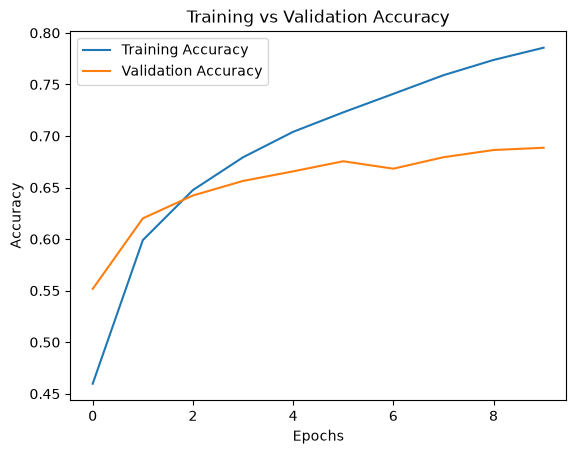

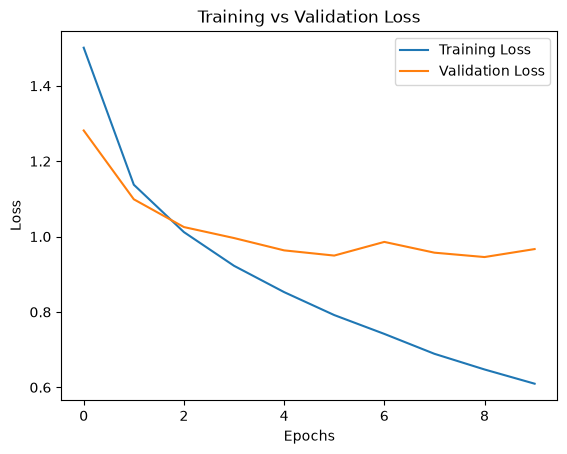

In [14]:
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

And they clearly show overfitting:

Accuracy: training keeps rising (~46% → 80%), while validation levels around ~67–68%.
Loss: training keeps falling, while validation loss starts rising/fluctuating after about epoch 5.

So your basic CNN is learning the training data increasingly well but not improving much on unseen data.

That is exactly what we wanted to observe before we add Dropout, Batch Normalization, and Early Stopping.

After each batch, weights are updated. After all batches finish → 1 epoch.
This repeats 10 times, and generally the model improves as it sees the training data repeatedly.

Technique	          Main purpose
Dropout	           Reduce overfitting

1. What is Dropout?
Suppose your Dense layer has 64 neurons:

64 neurons
● ● ● ● ● ● ● ● ● ● ...

Normally, during training, all 64 participate.
With dropout, we randomly turn off some neurons for that training step.
For example, with:

Dropout(0.5)

roughly 50% of the neurons are randomly dropped for each training step.

Conceptually:

Before dropout:

● ● ● ● ● ● ● ●
↓ ↓ ↓ ↓ ↓ ↓ ↓ ↓

After dropout:


● ✕ ● ✕ ✕ ● ● ✕

The ✕ neurons do not participate in that particular training step.

2. Why would we deliberately turn neurons off?
Because we want to prevent the network from becoming too dependent on particular neurons.

Your current model is doing this:
"I can memorize very specific patterns in the training data."

That's why:
Training accuracy → ~80%
Validation accuracy → ~68%

The model is becoming too specialized to the training data.
Dropout forces the network to work with different combinations of neurons during training.

So instead of:
"I always depend on these particular neurons."

the network is encouraged to learn:
"I need to learn more robust patterns that work even when some neurons aren't available."

That helps reduce overfitting.

What does 0.5 actually mean?
Dropout(0.5)
means:
During training, randomly drop 50% of the neurons/activations for each training step.

Similarly:
Dropout(0.2)
means:
Drop about 20%.

It does not mean "remove those neurons permanently."
The neurons are randomly dropped temporarily during training.

Dropout is active during training, but not during testing/inference.
So:

TRAINING:
Random neurons turned off
        ↓
Model learns robust patterns


TESTING:
All neurons available
        ↓
Make prediction

You don't lose half of your model permanently.

Where will we put Dropout in our CNN?
Your current ending is approximately:

Flatten
   ↓
Dense(64)
   ↓
Dense(10)

We'll change it to:

Flatten
   ↓
Dense(64)
   ↓
Dropout(0.5)
   ↓
Dense(10)

So the dropout is applied after the Dense(64) layer and before the final classification layer.

Dropout(0.5) means roughly 50% of the 64 activations are randomly dropped during each training step. ✅ “50% of the 64 neuron activations are randomly dropped during training.”
We don't manually know which ones are dropped; they are chosen randomly each step. ✅
Then the remaining activations are passed to Dense(10). ✅

In [15]:
modell=models.Sequential([
    layers.Conv2D(
        32,(3,3),
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(
        64,(3,3),
        activation='relu'
    ),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10,activation='softmax')


])

In [16]:
modell.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
history_drop=modell.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.3558 - loss: 1.7373 - val_accuracy: 0.5062 - val_loss: 1.4281
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.4823 - loss: 1.4427 - val_accuracy: 0.5745 - val_loss: 1.2095
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5232 - loss: 1.3209 - val_accuracy: 0.5949 - val_loss: 1.1525
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5590 - loss: 1.2318 - val_accuracy: 0.6079 - val_loss: 1.0901
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5793 - loss: 1.1757 - val_accuracy: 0.6432 - val_loss: 1.0237
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.5957 - loss: 1.1300 - val_accuracy: 0.6482 - val_loss: 1.0219
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6123 - loss: 1.0826 - val_accuracy: 0.6667 - val_loss: 0.9628
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6245 - loss: 1.0524 -

 if you train for 10 epochs, the model normally ends with the weights from the 10th (last) epoch.

The assumption is simply that more training will generally improve the model, but that is not always true because overfitting can happen.

CNN + Dropout:

Training accuracy ≈ 63.9%
Validation accuracy ≈ 65.2%

The important thing is that the gap became much smaller.
Why did training accuracy decrease? Because Dropout deliberately makes training harder by randomly dropping activations.

So Dropout is doing its job: reducing overfitting, even though the training accuracy itself becomes lower.

One more thing: your validation accuracy with Dropout hasn't become higher yet, so we shouldn't say Dropout made the model better overall. It made the model less overfitted.

but it's like at the very first time, it was 79% accuracy for the training. But now it dropped to 63. So, for solving overfitting, is that okay to like compromise with this?

Yes, to some extent. ✅
The goal is not to maximize training accuracy. The goal is to get good validation/test accuracy with a small gap from training accuracy.

In your case:
Before Dropout: 79.5% train vs 68.3% validation → large gap → overfitting.
After Dropout: 63.9% train vs 65.2% validation → very small gap → much less overfitting.

But 63.9% training accuracy is lower than we'd ideally want. So we don't simply accept the lower accuracy and stop.

We now try Batch Normalization and/or train longer, and see whether we can get:

higher validation accuracy + controlled overfitting.

We want a balance: high enough training accuracy, with a small train–validation gap.

In [18]:
#0.2 → drops only 20% → gives the model more capacity while still providing some regularization.

modelll=models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10,activation='softmax')
])

In [19]:
modelll.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

history_drop2=modelll.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.4117 - loss: 1.6048 - val_accuracy: 0.5334 - val_loss: 1.3242
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5453 - loss: 1.2799 - val_accuracy: 0.5637 - val_loss: 1.2372
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5935 - loss: 1.1526 - val_accuracy: 0.6399 - val_loss: 1.0472
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.6234 - loss: 1.0658 - val_accuracy: 0.6462 - val_loss: 0.9962
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6496 - loss: 0.9956 - val_accuracy: 0.6698 - val_loss: 0.9408
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.6692 - loss: 0.9414 - val_accuracy: 0.6634 - val_loss: 0.9537
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.6854 - loss: 0.8940 - val_accuracy: 0.6718 - val_loss: 0.9428
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7007 - loss: 0.8475 -

This is much better than Dropout(0.5). ✅
At the final epoch:

Training accuracy: 72.35%
Validation accuracy: 68.60%
Gap: only about 3.75%

So Dropout(0.2) is a better balance for our model: it reduced overfitting without hurting training accuracy as much as 0.5.
Also notice the validation loss is still decreasing overall, reaching 0.9023, which is a good sign.

0.2 gives the model more neurons to learn while still providing some protection against overfitting.

The goal is a good balance:
High enough training accuracy + small train/validation gap + high validation/test accuracy. ✅

In [20]:
model_bn = models.Sequential([
    layers.Conv2D(32,(3,3),input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3)),
    layers.BatchNormalization(),
    layers.Activation('relu'),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10,activation='softmax')
])

You mean: “I already ran the previous code with Dropout(0.2). Why do I have to write Dropout(0.2) again in the new Batch Normalization code?”

Because when you create a new Sequential model, it is a completely new model. The previous model's layers are not automatically carried into it.
New BatchNorm model → must include Dropout(0.2) again if we want the new model to have both BatchNorm + Dropout.

For one input image, each neuron produces a value.

Suppose the 64 neurons produce:

-2, 3, -1, 5, 0, 4, ...

Then ReLU does:

0, 3, 0, 5, 0, 4, ...

So:

The 64 neurons still exist.
But some produce 0, so their output contributes nothing to the next layer.
Others produce positive values, so their output passes forward.

So ReLU's job is not to create the neurons or activate all of them.

Its job is:

Take each neuron's output and set negative values to 0, while keeping positive values.

That's why we say ReLU decides which neuron outputs are active/pass through. ✅

Think of Batch Normalization as a “value stabilizer.”
During training, the values coming out of a layer can become very large, very small, or vary a lot. Batch Normalization normalizes those values into a more controlled range before passing them to the next step.

So:
Conv2D → Batch Normalization → ReLU

Meaning:
Convolution extracts features → BatchNorm stabilizes the values → ReLU activates them.

If a neuron's value is 0:
BatchNorm → normalizes it → ReLU still gives 0 → it contributes nothing to the next layer.

But the neuron itself still exists as one of the 64 neurons.

✅ ReLU helps the network keep positive outputs and suppress negative ones (set them to 0), which helps focus on useful patterns.

In [21]:
model_bn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    
)

history_bn=model_bn.fit(X_train,y_train,epochs=10,batch_size=32,
                     validation_split=0.2)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 16ms/step - accuracy: 0.4080 - loss: 1.6104 - val_accuracy: 0.5301 - val_loss: 1.3309
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 13ms/step - accuracy: 0.5160 - loss: 1.3324 - val_accuracy: 0.4525 - val_loss: 1.6684
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 16ms/step - accuracy: 0.5609 - loss: 1.2249 - val_accuracy: 0.5085 - val_loss: 1.4674
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.5819 - loss: 1.1600 - val_accuracy: 0.6037 - val_loss: 1.1445
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6062 - loss: 1.1054 - val_accuracy: 0.6279 - val_loss: 1.0584
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 18s 14ms/step - accuracy: 0.6209 - loss: 1.0582 - val_accuracy: 0.5948 - val_loss: 1.1803
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6370 - loss: 1.0256 - val_accuracy: 0.6231 - val_loss: 1.0821
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 14ms/step - accuracy: 0.6430 -

So Batch Normalization made the train–validation gap smaller, but it did not improve validation accuracy in this 10-epoch run.

So don't conclude that BatchNorm is always better. In our particular experiment, Dropout(0.2) actually gave slightly better validation accuracy.

And notice something interesting: your validation accuracy is quite fluctuating (for example, 64.53% → 59.90% → 67.78% → 59.72% → 68.15%). That's one reason Early Stopping becomes useful.

In our experiments, Dropout(0.2) gave the better balance:
72.35% training accuracy + 68.60% validation accuracy → 3.75% gap.

What is Early Stopping?
Early Stopping is a technique that automatically stops training when the model stops improving on the validation data.

Remember what happened with your original CNN:
Training accuracy → keeps increasing
Validation accuracy → stops improving

If we keep training, the model may start learning the training data too specifically → overfitting.

Early Stopping says:
“Validation performance isn't improving anymore, so stop training.”

What is patience?
For example:
EarlyStopping(monitor='val_loss', patience=3)

means:
Monitor validation loss. If it doesn't improve for 3 consecutive epochs, stop training.

Example:

Epoch 5 → best val_loss
Epoch 6 → worse
Epoch 7 → worse
Epoch 8 → worse
→ STOP

What is restore_best_weights=True?
Suppose:

Epoch 5 → best model
Epoch 6 → worse
Epoch 7 → worse
Epoch 8 → worse → training stops

restore_best_weights=True tells Keras:
Go back to the weights from Epoch 5, rather than keeping the worse weights from Epoch 8.

So why is Early Stopping useful?
It saves training time and helps prevent overfitting.
And importantly, it doesn't change the neurons or weights directly like Dropout. It simply decides when to stop training.

For our project, we'll now add Early Stopping to your Dropout(0.2) model, since that was our better-performing version.

In [22]:
from tensorflow.keras.callbacks import EarlyStopping

In [23]:
early_stop=EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [24]:
history_early=modelll.fit(
    X_train,y_train,epochs=20,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.7343 - loss: 0.7497 - val_accuracy: 0.6915 - val_loss: 0.8990
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7435 - loss: 0.7144 - val_accuracy: 0.6919 - val_loss: 0.9019
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7566 - loss: 0.6848 - val_accuracy: 0.7009 - val_loss: 0.8916
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7598 - loss: 0.6660 - val_accuracy: 0.7008 - val_loss: 0.9338
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.7703 - loss: 0.6360 - val_accuracy: 0.6910 - val_loss: 0.9327
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7761 - loss: 0.6183 - val_accuracy: 0.6835 - val_loss: 0.9962


Notice we used 20 epochs, not 10. That's intentional: we're giving the model more opportunities to learn, and Early Stopping will stop it automatically when validation loss stops improving.

Normally, after training finishes, the model has the weights from the final epoch.

With restore_best_weights=True:
Training continues → best validation-loss epoch is identified → training stops → model restores the weights from that best epoch.

In your case, Epoch 2 was the best, so the model keeps Epoch 2's weights, not Epoch 5's.

You can use Dropout + Batch Normalization + Early Stopping together, or use only some of them.

In our experiment, Batch Normalization didn't improve our validation result, so we're keeping the better-performing setup:

Dropout(0.2) + Early Stopping.

It's a practical model-selection decision based on our results.

In [25]:
#Now evaluate the final model on the test set.

test_loss,test_accuracy=modelll.evaluate(X_test,y_test)
print("Test Loss:",test_loss)
print("Test Accuracy:",test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6967 - loss: 0.9163
Test Loss: 0.9163006544113159
Test Accuracy: 0.6966999769210815


✅ Your final test result is:

Test Accuracy = 69.20%
Test Loss = 0.9271

This means your final CNN correctly classified about 69 out of every 100 unseen CIFAR-10 images.

And importantly, your validation accuracy was around 69%, and your test accuracy is 69.2%, so they are very close. That's a good sign that the model is generalizing reasonably well rather than heavily overfitting.

What is Data Augmentation?

Suppose CIFAR-10 gives us this training image of a car:

Original image → 🚗

Data augmentation takes that same image and makes a slightly modified version:

flip it horizontally → 🚗←
slightly rotate it
slightly zoom in
slightly shift it

So we might get:

Original car → flipped car → shifted car → slightly rotated car

But all of them still mean “car.”

So data augmentation is basically:

Creating different-looking versions of our existing training images without changing their correct label.

Why do we do this?

Remember the problem we were trying to solve earlier: overfitting.

Suppose our CNN sees these training images:

car in center
car in center
car in center
car in center

The model might become very good at recognizing these particular appearances rather than learning the general concept of a car.

Then it gets a new image:

car slightly shifted to the side

and struggles.

Data augmentation says:

"Don't just train on the exact images I gave you. Train on slightly different versions too."

Now the CNN sees:

car in center
car shifted
car flipped
car slightly rotated
car zoomed

So the model is forced to learn:

“What makes this a car?”

rather than:

“This exact pixel arrangement means car.”

The most important thing

Data augmentation doesn't create new labels.

Suppose:

Original image → Cat
Flipped image  → Cat
Shifted image  → Cat
Rotated image  → Cat

The image changes, but the meaning doesn't change.

That's why those transformations are useful.

And this is exactly why we are adding augmentation after Dropout and Batch Normalization in our CIFAR-10 project: we're now trying another way to improve generalization and reduce overfitting.

Data augmentation is applied only to the training data.
Because the training data is used to teach the model, while validation/test data is used to fairly evaluate it.

So the rule is:
Augment training data to improve learning; keep validation and test data unchanged to measure performance fairly.

1. Random Horizontal Flip
The image is sometimes flipped left-to-right.

Why?
A cat facing left and the same cat facing right are still cats.
So this teaches the CNN that the class shouldn't depend on the object's left/right orientation.

2. Random Rotation
We slightly rotate the image.

For example:
0° → 5° → -5°

Why?
Real-world objects are rarely perfectly aligned.

3. Random Zoom
We slightly zoom in or out.

Why?
The object may appear at different sizes in real images.

4. Random Translation
We slightly move the image horizontally or vertically.

Why?
The object doesn't always appear exactly in the center.

So our idea is:
Original training image → small random changes → more variety → better generalization → less overfitting.

In [28]:
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomTranslation,
    RandomZoom,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization,
    Activation

    
)

data_augmentation=models.Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
    RandomTranslation(0.1,0.1)
])

Why 0.1 in RandomRotation?
RandomRotation(0.1)
Here 0.1 means a fraction of a full rotation:

0.1 × 360° = 36°
So Keras can randomly rotate the image within roughly ±36°.
We don't want huge rotations because CIFAR-10 objects could become unrealistic.

Why 0.1 in RandomZoom?
RandomZoom(0.1)
This means a small amount of random zooming, around 10%.
The purpose is simply to make the object appear slightly bigger or smaller.


Why 0.1, 0.1 in RandomTranslation?
RandomTranslation(0.1, 0.1)
The first 0.1 = maximum vertical translation (10% of image height).
The second 0.1 = maximum horizontal translation (10% of image width).
So the object can move a little up/down and left/right.

Why RandomFlip("horizontal")?
RandomFlip("horizontal")
It randomly flips the image left ↔ right.
We use horizontal flipping because for many CIFAR-10 classes, a horizontally flipped object is still the same class.

For example:
car facing left → car facing right
Still a car.

Training: Augmentation ✅ + Dropout ✅
Validation: Augmentation ❌ + Dropout ❌
Test: Augmentation ❌ + Dropout ❌

This happens automatically when Keras evaluates the model.

In [30]:

model_augment=models.Sequential([
    data_augmentation,
    Conv2D(32,(3,3),input_shape=(32,32,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3)),
    BatchNormalization(),
    Activation('relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(64),
    Activation('relu'),
    Dropout(0.2),

    Dense(10,activation='softmax')
    

])

r:\C\PYTHON PROGRAMS\Deep Learning Proj 2 (CNN proj 1)\.venv-1\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model_augment.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']

)

In [33]:
history_augment=model_augment.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 52s 42ms/step - accuracy: 0.4662 - loss: 1.4705 - val_accuracy: 0.4840 - val_loss: 1.4823
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 64s 51ms/step - accuracy: 0.4860 - loss: 1.4266 - val_accuracy: 0.4917 - val_loss: 1.5206
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.4978 - loss: 1.3922 - val_accuracy: 0.4731 - val_loss: 1.6014
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 84s 67ms/step - accuracy: 0.5119 - loss: 1.3693 - val_accuracy: 0.5731 - val_loss: 1.2373
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.5188 - loss: 1.3463 - val_accuracy: 0.5857 - val_loss: 1.1911
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 85s 68ms/step - accuracy: 0.5269 - loss: 1.3237 - val_accuracy: 0.5455 - val_loss: 1.2933
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.5319 - loss: 1.3045 - val_accuracy: 0.5740 - val_loss: 1.2085
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 87s 69ms/step - accuracy: 0.5404 -

Your final epoch
Training accuracy: 55.40%
Validation accuracy: 60.55%
Training loss: 1.2592
Validation loss: 1.1351
What does this tell us?

The interesting part is:
Validation accuracy > Training accuracy

That is completely possible when using data augmentation + dropout.

Why? During training, the model sees augmented, harder images and dropout is also active. During validation, the model sees the original, unaugmented images and dropout is turned off.
So training is harder than validation.

Most importantly
We're not seeing severe overfitting here.

At epoch 10:

Train accuracy       = 55.4%
Validation accuracy  = 60.55%
Gap                  = 5.15%

And validation accuracy reached 60.55%, which is a pretty useful result for our experiment.
However, we should not conclude that augmentation definitely improved the model yet. We need to compare these numbers with the results from our previous BatchNorm model.